# Elevator

A worked example of `FormalVizWidget` built from
`spec/ElevatorSpectabular.ipynb`'

The SVG is adapted from `report/report.ipynb` section 11's Anywidget prototype
(`ElevatorFormalWidget`), reduced from 5 to 3 floors and adapted to the
real spec's variables (`floor`, `dir`, `b1u`/`b2u`/`b2d`/`b3d`,
`c1`/`c2`/`c3`). The door from that prototype is dropped for now.

Pull the framework notebook into this kernel first:

In [1]:
%run "../FormalVizWidget.ipynb"

## State & rendering

`state` is the spec's own variables: which floor the cabin is at, its
travel direction, the four exterior call buttons, and the three cabin
buttons. `_bind_elevator` declares `widget["selector.prop"] = (fn, method)`
bindings that move the cabin to the new floor's height, toggle each
button indicator, and update the direction/request text. See
`FormalVizWidget.ipynb`'s "Binding SVG properties to state" section.

In [2]:
INITIAL_STATE = {
    "floor": "F1",
    "dir": "Idle",
    "b1u": False,
    "b2u": False,
    "b2d": False,
    "b3d": False,
    "c1": False,
    "c2": False,
    "c3": False,
}

FLOOR_Y = {"F1": 130, "F2": 80, "F3": 30}
BTN_ON = "#ff9800"
BTN_OFF = "#bdbdbd"
EXT_BUTTONS = ["b1u", "b2u", "b2d", "b3d"]
CAB_BUTTONS = ["c1", "c2", "c3"]
DIR_LABEL = {"Up": "▲ up", "Down": "▼ down", "Idle": "● idle"}

def create_elevator_widget(svg_path="Elevator.svg", viewbox=None):
    w = ElevatorWidget.from_svg(svg_path, variables=INITIAL_STATE, viewbox=viewbox)

    # cabin moves to the new floor's height. tween-vs-snap is no longer
    # hand-tagged: anim_algebra.svg_diff infers it per transition by
    # diffing the rendered frame before and after.
    w["cabin-group.transform"] = (
        lambda s: ("translate", (0, FLOOR_Y[s['floor']] - FLOOR_Y['F1']))
    )

    # each call/cabin button lights up while pressed
    for name in EXT_BUTTONS + CAB_BUTTONS:
        w[f"btn-{name}.fill"] = (
            lambda s, name=name: BTN_ON if s[name] else BTN_OFF
        )

    # panel text: never animated regardless of binding, same as before
    w["floor-display.text"] = lambda s: s["floor"]
    w["dir-display.text"] = lambda s: DIR_LABEL.get(s["dir"], s["dir"])
    w["req-display.text"] = (
        lambda s: "requests: " + (", ".join(n for n in EXT_BUTTONS if s[n]) or "none")
    )
    w["cab-display.text"] = (
        lambda s: "cabin: " + (", ".join(n for n in CAB_BUTTONS if s[n]) or "none")
    )

    return w


## Spectabular spec:
`ElevatorSpectabular.ipynb`'s own first cell does
`%run "spectabular.ipynb"`, which is a path relative to *its own* directory
(`spec/`). A nested `%run` doesn't change the kernel's working directory,
so invoking it directly from here (cwd `anywidget/elevator/`) would still
look for `spectabular.ipynb` beside this notebook and fail. To fix this,`chdir`
into `spec/` for the duration of the `%run`, then back.

In [3]:
import os

here = os.getcwd()
os.chdir("../../spec")
get_ipython().run_line_magic("run", '"ElevatorSpectabular.ipynb"')
os.chdir(here)

## `ElevatorWidget`

In [4]:
elevatorSpec = buttonEvent | arrivalEvent


class ElevatorWidget(FormalVizWidget):
    spec = elevatorSpec

## Usage

Each cell below is independently runnable once the cells above have
executed.

Create the widget:

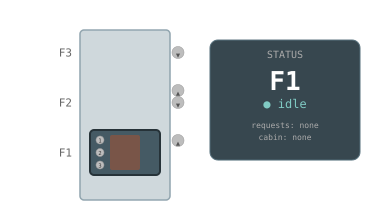

In [5]:
w = create_elevator_widget(viewbox="0 0 380 220")
w

Press the floor-2 up button, then arrive at F2 (which clears it and stops, since nothing else is pending):

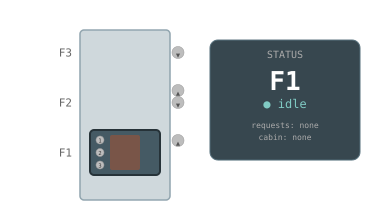

In [6]:
display(w)
next_state = w.compute_next_state(w.state, ev="Press2U")
await w.transition(next_state, duration=0.3)
next_state = w.compute_next_state(w.state, ev="ArrF2")
await w.transition(next_state, duration=0.6)

A passenger inside presses cabin button 3 (`PressC3`), and someone outside calls for floor 2 going up (`Press2U`): the elevator heads up and, following the elevator algorithm, continues past floor 2 to floor 3 first, since a request remains above:

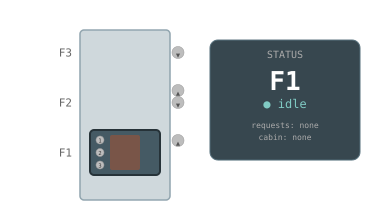

In [17]:
display(w)
await reset_and_run(w, run_scenario, [
    {"ev": "PressC3"},
    {"ev": "Press2U"},
    {"ev": "ArrF2"},   # continues Up: c3 still pending above
    {"ev": "ArrF3"},   # no requests above F3 now: stops
], transition_dur=0.6)

Press the floor-2 *down* button while idle below it: the elevator must first travel up to fetch the passenger, then reverses direction immediately on arrival, since the only pending request is behind it, and continues back down:

In [18]:
await reset_and_run(w, run_scenario, [
    {"ev": "Press2D"},
    {"ev": "ArrF2"},   # reqAboveF2 false, b2d true: reverses to Down
    {"ev": "ArrF1"},
], transition_dur=0.6)

## Branching and history

`w` above just finished the "press 2-down" scenario: idle at F1, called
down from F2, forced up to fetch the passenger, then back down to F1.
Every `FormalVizWidget` keeps a local record of the states it passed
through to get there (`w.history`, `w.export_trace()`), independent of
any other widget. Moving around in that record with `w.goto_transition()`
/ `w.prev()` / `w.next()` doesn't touch what's recorded, so it's safe to
scrub back and forth:

3 transitions recorded, currently at 3


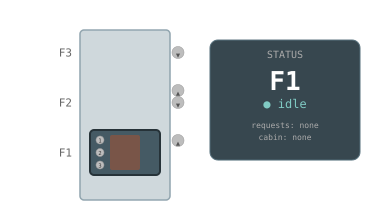

2 F2 Down False


In [9]:
print(f"{len(w)} transitions recorded, currently at {w.cursor}")
display(w)
w.goto_transition(0, duration=0.3)   # back to idle at F1, before the call was pressed
w.prev(duration=0.3)                 # no-op, already at the start
w.next(duration=0.3)                 # -> after Press2D (button lit, still idle)
w.next(duration=0.3)                 # -> after ArrF2 (arrived, b2d cleared, now heading Down)
print(w.cursor, w.state["floor"], w.state["dir"], w.state["b2d"])

`w.snapshot()` forks a brand-new, independent widget from wherever `w`
currently is (right now that's mid-scenario, cursor 2 of 3, just after
arriving at F2 and reversing to head back Down). It carries along the
history that led there, but from this point on nothing that happens to
one widget touches the other. Below, `w` continues exactly as originally
scripted (arrives at F1), while `w_branch` instead registers a cabin call
without an arrival, so it stays put at F2:

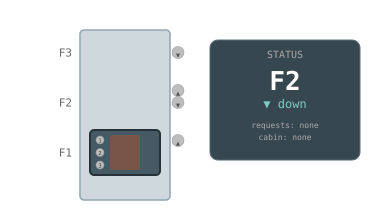

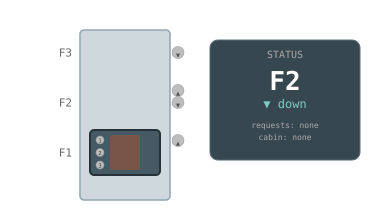

w:        F1 Idle
w_branch: F2 Down c3 pending: True


In [10]:
display(w)
w_branch = w.snapshot()
display(w_branch)

# w finishes the scripted run: down to F1
next_state = w.compute_next_state(w.state, ev="ArrF1")
await w.transition(next_state, duration=0.4, event={"ev": "ArrF1"})

# w_branch instead gets a cabin call while still en route (still heading
# Down, so this just registers the request rather than redirecting it)
next_state = w_branch.compute_next_state(w_branch.state, ev="PressC3")
await w_branch.transition(next_state, duration=0.4, event={"ev": "PressC3"})

print("w:       ", w.state["floor"], w.state["dir"])
print("w_branch:", w_branch.state["floor"], w_branch.state["dir"], "c3 pending:", w_branch.state["c3"])

`w.replay()` re-animates already-recorded history in order, without
calling `compute_next_state` again. Handy for replaying a demo exactly
as it happened, even against a nondeterministic spec where re-solving
might pick a different branch. `w.export_trace()` dumps that same history
as plain data:

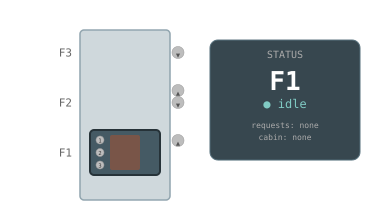

replayed back to cursor 3 of 3
0 {'ev': 'Press2D'} -> F1 Up
1 {'ev': 'ArrF2'} -> F2 Down
2 {'ev': 'ArrF1'} -> F1 Idle


In [11]:
display(w)
w.goto_transition(0)
await w.replay(tick_dt=0.4, transition_dur=0.4)
print(f"replayed back to cursor {w.cursor} of {len(w)}")

for step in w.export_trace():
    print(step["index"], step["event"], "->", step["after"]["floor"], step["after"]["dir"])

## Printable per-step snapshots

For a report figure you usually want a handful of *static* frames, one
per step of a scenario, that stay put no matter what you run afterward.
Displaying the same driving widget repeatedly doesn't give you that.
Every output cell showing it just tracks wherever `state` moves to next,
so re-running or extending the notebook changes figures you
already displayed. Below, each cell actually runs `demo.transition(...)` the formal state only advances once that's called, and then
immediately `snapshot()`s the result into its own independent widget, so
every figure is frozen at that step for good: safe to screenshot,
export, or embed individually in the report.

Step 0: idle at F1, nothing pending:

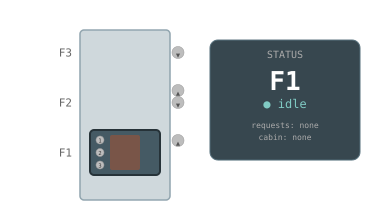

In [12]:
demo = create_elevator_widget(viewbox="0 0 380 220")
fig_idle = demo.snapshot()
display(fig_idle)

Step 1: the floor-2 up button is pressed:

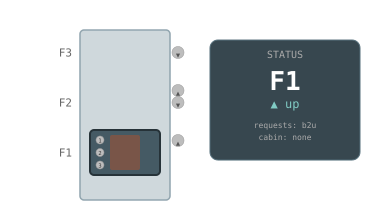

In [13]:
next_state = demo.compute_next_state(demo.state, ev="Press2U")
await demo.transition(next_state, duration=0.4, event={"ev": "Press2U"})
fig_pressed = demo.snapshot()
display(fig_pressed)

Step 2: the cabin arrives at F2 and the call clears:

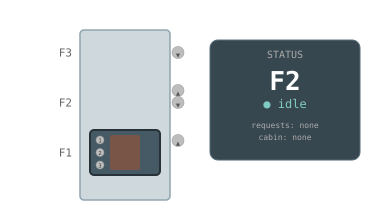

In [14]:
next_state = demo.compute_next_state(demo.state, ev="ArrF2")
await demo.transition(next_state, duration=0.4, event={"ev": "ArrF2"})
fig_arrived = demo.snapshot()
display(fig_arrived)

`fig_idle`, `fig_pressed`, `fig_arrived` are three independent widgets --
exactly the frozen frames you'd pull into the report. `demo` itself is
free to keep moving without touching any of them:

In [15]:
demo.reset()
print("demo:       ", demo.state)
print("fig_idle:   ", fig_idle.state)
print("fig_pressed:", fig_pressed.state)
print("fig_arrived:", fig_arrived.state)

demo:        {'floor': 'F1', 'dir': 'Idle', 'b1u': False, 'b2u': False, 'b2d': False, 'b3d': False, 'c1': False, 'c2': False, 'c3': False}
fig_idle:    {'floor': 'F1', 'dir': 'Idle', 'b1u': False, 'b2u': False, 'b2d': False, 'b3d': False, 'c1': False, 'c2': False, 'c3': False}
fig_pressed: {'b2u': True, 'b3d': False, 'floor': 'F1', 'c3': False, 'c1': False, 'b1u': False, 'dir': 'Up', 'c2': False, 'b2d': False}
fig_arrived: {'b2u': False, 'b3d': False, 'floor': 'F2', 'c3': False, 'c1': False, 'b1u': False, 'dir': 'Idle', 'c2': False, 'b2d': False}
